# ESDA: Spatial Dependence of GDP across 514 Districts in Indonesia

**Focus:** Exploratory Spatial Data Analysis (ESDA) of district-level GDP in Indonesia for **2010** and **2025**.

**Key Concepts:** Spatial Autocorrelation · Global Moran's I · Local Indicators of Spatial Association (LISA) · Choropleth Mapping

**Data:**
- GDP: [`quarcs-lab/indonesia514`](https://github.com/quarcs-lab/indonesia514/blob/main/gdp/gdp.csv)
- Map (actual polygons): `maps/mapIndonesia514_new.geojson`
- Map (Thiessen polygons for W matrix): `maps/mapIndonesia514_new_tp.geojson`

> **Note on spatial weights:** Indonesia is an archipelago. Standard queen/rook contiguity based on actual district polygons will disconnect many island districts. We use **Thiessen (Voronoi) polygons** — which tile the full extent — to construct a queen contiguity weight matrix that captures spatial proximity across sea boundaries.

**Authors:** Mendez, C., Abdulah, R., & Arvianto, B. (2026). *Indonesia514*. QuaRCS Lab.

---

## 0 | Install & Import Libraries

In [1]:
# Install required packages (run once in Colab)
!pip install pysal libpysal esda splot geopandas mapclassify -q

In [2]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches

# PySAL / ESDA
import libpysal
from libpysal.weights import Queen
from esda.moran import Moran, Moran_Local
from splot.esda import (
    moran_scatterplot,
    plot_moran,
    lisa_cluster,
    plot_local_autocorrelation
)
import splot

# Display settings
pd.set_option('display.float_format', '{:.2f}'.format)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

print('Libraries loaded successfully.')
print(f'  geopandas : {gpd.__version__}')
print(f'  libpysal  : {libpysal.__version__}')
print(f'  esda      : {splot.__version__}')

Libraries loaded successfully.
  geopandas : 1.1.3
  libpysal  : 4.14.1
  esda      : 1.1.7


## 1 | Load Data

In [3]:
# ---------------------------------------------------------------------------
# 1.1  Define source URLs
# ---------------------------------------------------------------------------
REPO_URL = "https://raw.githubusercontent.com/quarcs-lab/indonesia514/main"

url_gdp    = f"{REPO_URL}/gdp/gdp.csv"
url_map    = f"{REPO_URL}/maps/mapIndonesia514_new.geojson"      # actual polygons (visualisation)
url_map_tp = f"{REPO_URL}/maps/mapIndonesia514_new_tp.geojson"   # Thiessen polygons (W matrix)

# ---------------------------------------------------------------------------
# 1.2  Load GDP data
# ---------------------------------------------------------------------------
print('Loading GDP data ...')
df_gdp = pd.read_csv(url_gdp)
df_gdp['districtID'] = df_gdp['districtID'].astype(str).str.zfill(4)

print(f'  Shape: {df_gdp.shape}')
print(f'  Columns: {list(df_gdp.columns)}')
df_gdp.head(3)

Loading GDP data ...
  Shape: (514, 28)
  Columns: ['fid', 'districtID', 'districtID_old', 'nameID', 'district_en', 'provinceID', 'province_bahasa', 'province_en', 'islandID', 'island_bahasa', 'island_en', 'district_bahasa', 'gdp_2010', 'gdp_2011', 'gdp_2012', 'gdp_2013', 'gdp_2014', 'gdp_2015', 'gdp_2016', 'gdp_2017', 'gdp_2018', 'gdp_2019', 'gdp_2020', 'gdp_2021', 'gdp_2022', 'gdp_2023', 'gdp_2024', 'gdp_2025']


,fid,districtID,districtID_old,nameID,district_en,provinceID,province_bahasa,province_en,islandID,island_bahasa,...,gdp_2016,gdp_2017,gdp_2018,gdp_2019,gdp_2020,gdp_2021,gdp_2022,gdp_2023,gdp_2024,gdp_2025
0,1,1101,1101,simeulue,Simeulue,11,Aceh,Aceh,1,Sumatera,...,1405.84,1467.98,1530.15,1600.52,1602.41,1657.03,1726.61,1806.62,1886.61,1958.50
1,2,1102,1102,acehsingkil,Aceh Singkil,11,Aceh,Aceh,1,Sumatera,...,1540.65,1600.98,1664.74,1731.17,1713.66,1780.42,1844.65,1909.66,1975.75,2043.19
2,3,1103,1103,acehselatan,South Aceh,11,Aceh,Aceh,1,Sumatera,...,3740.29,3887.22,4063.41,4243.40,4241.41,4345.78,4480.84,4639.20,4788.29,4931.74


In [4]:
# ---------------------------------------------------------------------------
# 1.3  Load GeoJSON files
# ---------------------------------------------------------------------------
print('Loading actual district polygons (for maps) ...')
gdf_map = gpd.read_file(url_map)
gdf_map['districtID'] = gdf_map['districtID'].astype(str).str.zfill(4)
print(f'  Shape: {gdf_map.shape}  |  CRS: {gdf_map.crs}')

print('Loading Thiessen polygons (for W matrix) ...')
gdf_tp = gpd.read_file(url_map_tp)
gdf_tp['districtID'] = gdf_tp['districtID'].astype(str).str.zfill(4)
print(f'  Shape: {gdf_tp.shape}  |  CRS: {gdf_tp.crs}')

Loading actual district polygons (for maps) ...
  Shape: (514, 9)  |  CRS: EPSG:4326
Loading Thiessen polygons (for W matrix) ...
  Shape: (514, 10)  |  CRS: EPSG:4326


## 2 | Merge GDP with GeoData

In [5]:
# Keep only the columns we need from the GDP data
gdp_cols = ['districtID', 'district_en', 'province_en', 'island_en',
            'gdp_2015', 'gdp_2025']
df_sub = df_gdp[gdp_cols].copy()

# Compute log GDP (better for spatial analysis; removes skewness)
df_sub['ln_gdp_2015'] = np.log(df_sub['gdp_2015'])
df_sub['ln_gdp_2025'] = np.log(df_sub['gdp_2025'])

# Compute GDP growth 2010-2025 (annualised, %)
df_sub['gdp_growth'] = ((df_sub['gdp_2025'] / df_sub['gdp_2015']) ** (1/9) - 1) * 100

# ---- Merge with actual map (for visualisation) ----
gdf = gdf_map.merge(df_sub, on='districtID', how='left')
print(f'Merged map GDF shape: {gdf.shape}')
print(f'Missing GDP values: {gdf["gdp_2015"].isna().sum()}')

# ---- Merge with Thiessen polygons (for W matrix) ----
gdf_tp_merged = gdf_tp.merge(df_sub, on='districtID', how='left')
# Ensure same row ordering for W matrix consistency
gdf_tp_merged = gdf_tp_merged.sort_values('districtID').reset_index(drop=True)
gdf = gdf.merge(
    gdf_tp_merged[['districtID']].reset_index().rename(columns={'index': 'tp_idx'}),
    on='districtID', how='left'
)

df_sub.describe()

Merged map GDF shape: (514, 17)
Missing GDP values: 0


,gdp_2015,gdp_2025,ln_gdp_2015,ln_gdp_2025,gdp_growth
count,514.00,514.00,514.00,514.00,514.00
mean,17604.03,26847.39,8.87,9.29,4.77
std,37897.65,58869.60,1.28,1.28,2.53
min,113.07,185.08,4.73,5.22,-1.98
25%,2913.84,4324.81,7.98,8.37,4.10
50%,6844.58,10866.08,8.83,9.29,4.64
75%,15849.45,24079.29,9.67,10.09,5.16
max,355092.53,560760.04,12.78,13.24,43.67


## 3 | Spatial Weights Matrix (Queen Contiguity via Thiessen Polygons)

Because Indonesia is an **archipelago**, we use Thiessen (Voronoi) polygons to build the spatial weights matrix.  
Thiessen polygons tile the entire geographic space without gaps, ensuring that island districts are connected to their nearest neighbours across sea boundaries — a standard approach for archipelagic countries.

> Reference: Anselin (1988); Rey & Anselin (2010)

In [6]:
from libpysal.weights import Queen, KNN
import matplotlib.pyplot as plt

# CRITICAL: sort + reset index BEFORE building W
gdf_tp_merged = gdf_tp_merged.sort_values('districtID').reset_index(drop=True)

# Build W — NO idVariable (use 0-based integer index)
print('Building Queen contiguity weights from Thiessen polygons ...')
W = Queen.from_dataframe(gdf_tp_merged)
W.transform = 'r'

print(f'\n--- Spatial Weights Summary ---')
print(f'  Number of observations : {W.n}')
print(f'  Min neighbours         : {W.min_neighbors}')
print(f'  Max neighbours         : {W.max_neighbors}')
print(f'  Mean neighbours        : {W.mean_neighbors:.2f}')
print(f'  Pct non-zero           : {W.pct_nonzero:.4f}%')
print(f'  Islands (0 neighbours) : {len(W.islands)}')

# Alignment check
print(f'\n--- Alignment Check ---')
print(f'  W.n == len(gdf_tp_merged) : {W.n == len(gdf_tp_merged)}')
print(f'  First 5 districtIDs       : {list(gdf_tp_merged["districtID"].values[:5])}')
print(f'  First 5 W keys            : {sorted(list(W.neighbors.keys()))[:5]}')

Building Queen contiguity weights from Thiessen polygons ...


/tmp/ipykernel_3499/3734592770.py:9: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  W = Queen.from_dataframe(gdf_tp_merged)



--- Spatial Weights Summary ---
  Number of observations : 514
  Min neighbours         : 2
  Max neighbours         : 15
  Mean neighbours        : 5.77
  Pct non-zero           : 1.1234%
  Islands (0 neighbours) : 0

--- Alignment Check ---
  W.n == len(gdf_tp_merged) : True
  First 5 districtIDs       : ['1101', '1102', '1103', '1104', '1105']
  First 5 W keys            : [0, 1, 2, 3, 4]


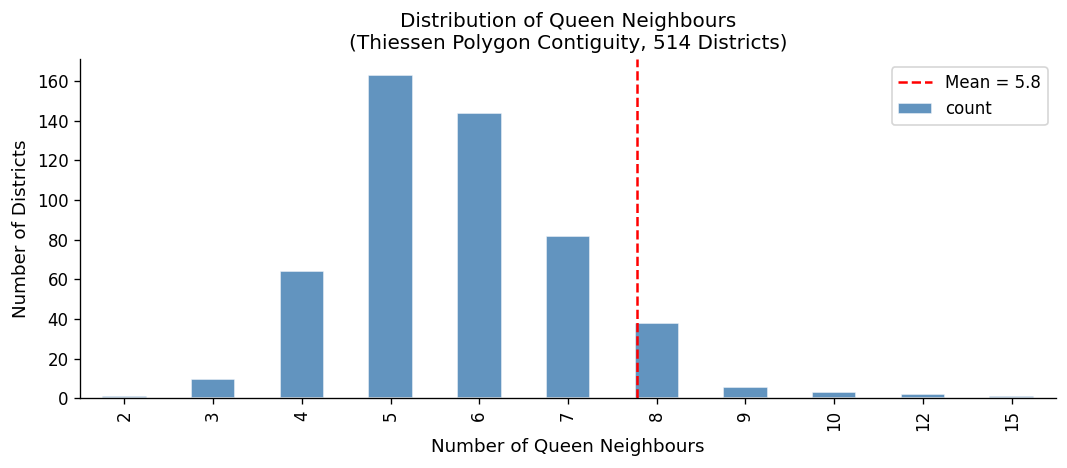

In [7]:
# Visualise neighbour count distribution
cardinalities = pd.Series(W.cardinalities)

fig, ax = plt.subplots(figsize=(9, 4))
cardinalities.value_counts().sort_index().plot(
    kind='bar', ax=ax, color='steelblue', alpha=0.85, edgecolor='white'
)
ax.set_xlabel('Number of Queen Neighbours', fontsize=11)
ax.set_ylabel('Number of Districts', fontsize=11)
ax.set_title('Distribution of Queen Neighbours\n(Thiessen Polygon Contiguity, 514 Districts)', fontsize=12)
ax.axvline(cardinalities.mean(), color='red',
           linestyle='--', linewidth=1.5, label=f'Mean = {cardinalities.mean():.1f}')
ax.legend()
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('fig5_neighbours_dist.png', dpi=150, bbox_inches='tight')
plt.show()

/tmp/ipykernel_3499/3564827708.py:2: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids = gdf_tp_merged.geometry.centroid


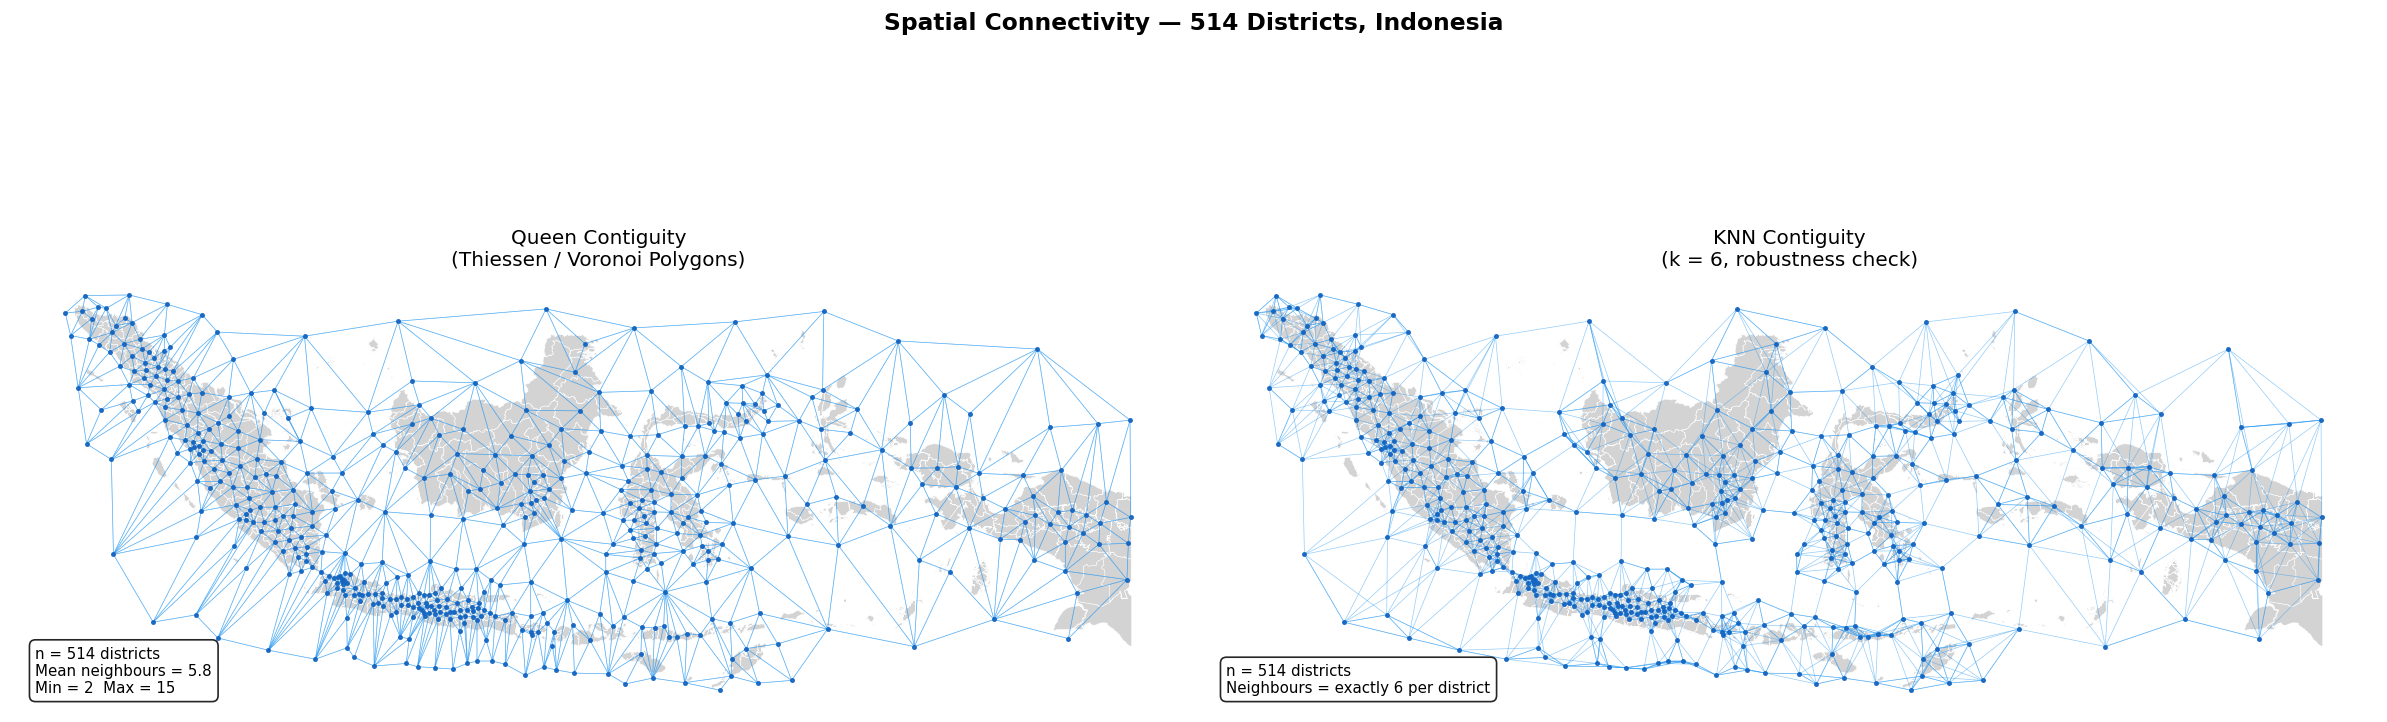

In [8]:
# Get centroids from Thiessen polygons
centroids = gdf_tp_merged.geometry.centroid
xs = centroids.x.values
ys = centroids.y.values

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle('Spatial Connectivity — 514 Districts, Indonesia',
             fontsize=14, fontweight='bold')

# --- Plot 1: Queen Contiguity (Thiessen) ---
ax = axes[0]
gdf_map.plot(ax=ax, color='#d3d3d3', edgecolor='white', linewidth=0.3)

for i, neighbours in W.neighbors.items():
    for j in neighbours:
        ax.plot([xs[i], xs[j]], [ys[i], ys[j]],
                color='#2196F3', linewidth=0.4, alpha=0.5, zorder=2)

ax.scatter(xs, ys, color='#1565C0', s=4, zorder=3, alpha=0.9)
ax.annotate(
    f'n = {W.n} districts\n'
    f'Mean neighbours = {W.mean_neighbors:.1f}\n'
    f'Min = {W.min_neighbors}  Max = {W.max_neighbors}',
    xy=(0.02, 0.04), xycoords='axes fraction', fontsize=9,
    bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.85)
)
ax.set_title('Queen Contiguity\n(Thiessen / Voronoi Polygons)', fontsize=12)
ax.set_axis_off()

# --- Plot 2: KNN k=6 (robustness check) ---
W_knn6 = KNN.from_dataframe(gdf_tp_merged, k=6)
W_knn6.transform = 'r'

ax = axes[1]
gdf_map.plot(ax=ax, color='#d3d3d3', edgecolor='white', linewidth=0.3)

for i, neighbours in W_knn6.neighbors.items():
    for j in neighbours:
        ax.plot([xs[i], xs[j]], [ys[i], ys[j]],
                color='#2196F3', linewidth=0.4, alpha=0.5, zorder=2)

ax.scatter(xs, ys, color='#1565C0', s=4, zorder=3, alpha=0.9)
ax.annotate(
    f'n = {W_knn6.n} districts\nNeighbours = exactly 6 per district',
    xy=(0.02, 0.04), xycoords='axes fraction', fontsize=9,
    bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.85)
)
ax.set_title('KNN Contiguity\n(k = 6, robustness check)', fontsize=12)
ax.set_axis_off()

plt.tight_layout()
plt.savefig('fig_spatial_connectivity.png', dpi=150, bbox_inches='tight')
plt.show()

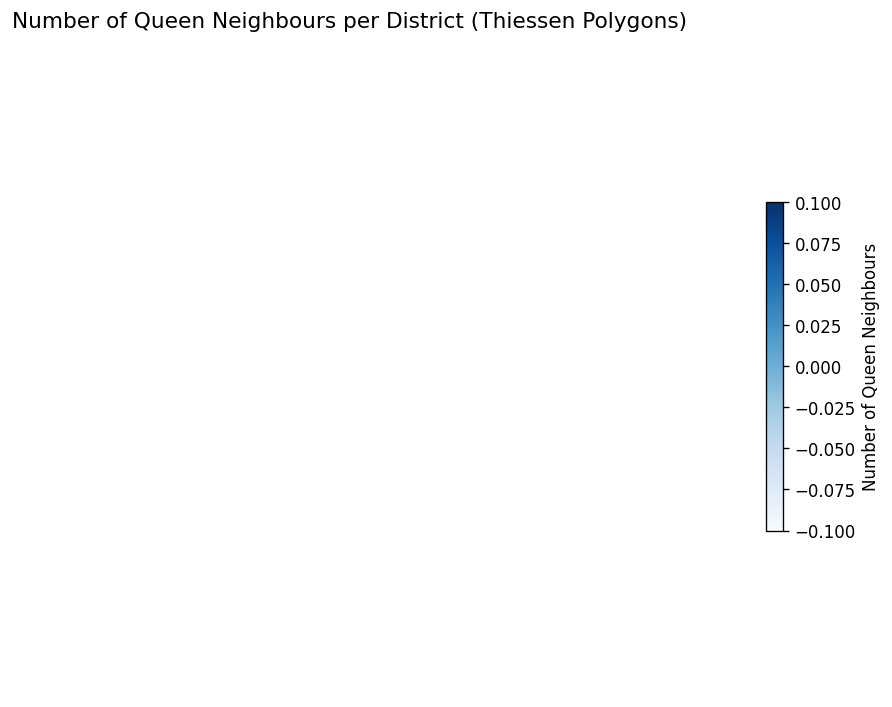

In [9]:
# Map: number of neighbours per district
gdf_tp_merged['n_neighbours'] = gdf_tp_merged['districtID'].map(W.cardinalities)

fig, ax = plt.subplots(figsize=(15, 6))
gdf_tp_merged.plot(
    column='n_neighbours', ax=ax, cmap='Blues',
    legend=True, edgecolor='grey', linewidth=0.1,
    legend_kwds={'label': 'Number of Queen Neighbours', 'shrink': 0.5}
)
ax.set_title('Number of Queen Neighbours per District (Thiessen Polygons)', fontsize=13)
ax.set_axis_off()
plt.tight_layout()
plt.savefig('fig6_neighbours_map.png', dpi=150, bbox_inches='tight')
plt.show()

## 4 | Global Spatial Autocorrelation — Moran's I

**Moran's I** measures whether similar values cluster together in space.

$$I = \frac{n}{\sum_i \sum_j w_{ij}} \cdot \frac{\sum_i \sum_j w_{ij}(x_i - \bar{x})(x_j - \bar{x})}{\sum_i (x_i - \bar{x})^2}$$

- $I > 0$ → positive spatial autocorrelation (spatial clustering)
- $I \approx 0$ → spatial randomness
- $I < 0$ → negative spatial autocorrelation (spatial dispersion)

In [10]:
# Align the GDP values with the W matrix row order (districtID order)
df_aligned = gdf_tp_merged[['districtID', 'ln_gdp_2015', 'ln_gdp_2025', 'gdp_growth']].copy()

# Fill any missing values with the mean (should be minimal)
for col in ['ln_gdp_2015', 'ln_gdp_2025', 'gdp_growth']:
    n_miss = df_aligned[col].isna().sum()
    if n_miss > 0:
        print(f'  Warning: {n_miss} missing values in {col} — filled with mean')
        df_aligned[col] = df_aligned[col].fillna(df_aligned[col].mean())

y_2015   = df_aligned['ln_gdp_2015'].values
y_2025   = df_aligned['ln_gdp_2025'].values
y_growth = df_aligned['gdp_growth'].values

# ---- Global Moran's I ----
print('Computing Global Moran\'s I ...')
moran_2015   = Moran(y_2015,   W, permutations=999)
moran_2025   = Moran(y_2025,   W, permutations=999)
moran_growth = Moran(y_growth, W, permutations=999)

print('\n' + '='*55)
print(f'{"Variable":<25} {"Moran\'s I":>10} {"p-value":>10} {"z-score":>10}')
print('-'*55)
for label, mi in [('Log GDP 2015',         moran_2015),
                  ('Log GDP 2025',         moran_2025),
                  ('Ann. Growth 2015–2025', moran_growth)]:
    sig = '***' if mi.p_sim < 0.01 else ('**' if mi.p_sim < 0.05 else ('*' if mi.p_sim < 0.10 else ''))
    print(f'{label:<25} {mi.I:>10.4f} {mi.p_sim:>10.4f} {mi.z_sim:>10.4f} {sig}')
print('='*55)
print('Significance: *** p<0.01  ** p<0.05  * p<0.10  (999 permutations)')

Computing Global Moran's I ...

Variable                   Moran's I    p-value    z-score
-------------------------------------------------------
Log GDP 2015                  0.5547     0.0010    21.2361 ***
Log GDP 2025                  0.5396     0.0010    20.2416 ***
Ann. Growth 2015–2025         0.1981     0.0010     9.0053 ***
Significance: *** p<0.01  ** p<0.05  * p<0.10  (999 permutations)


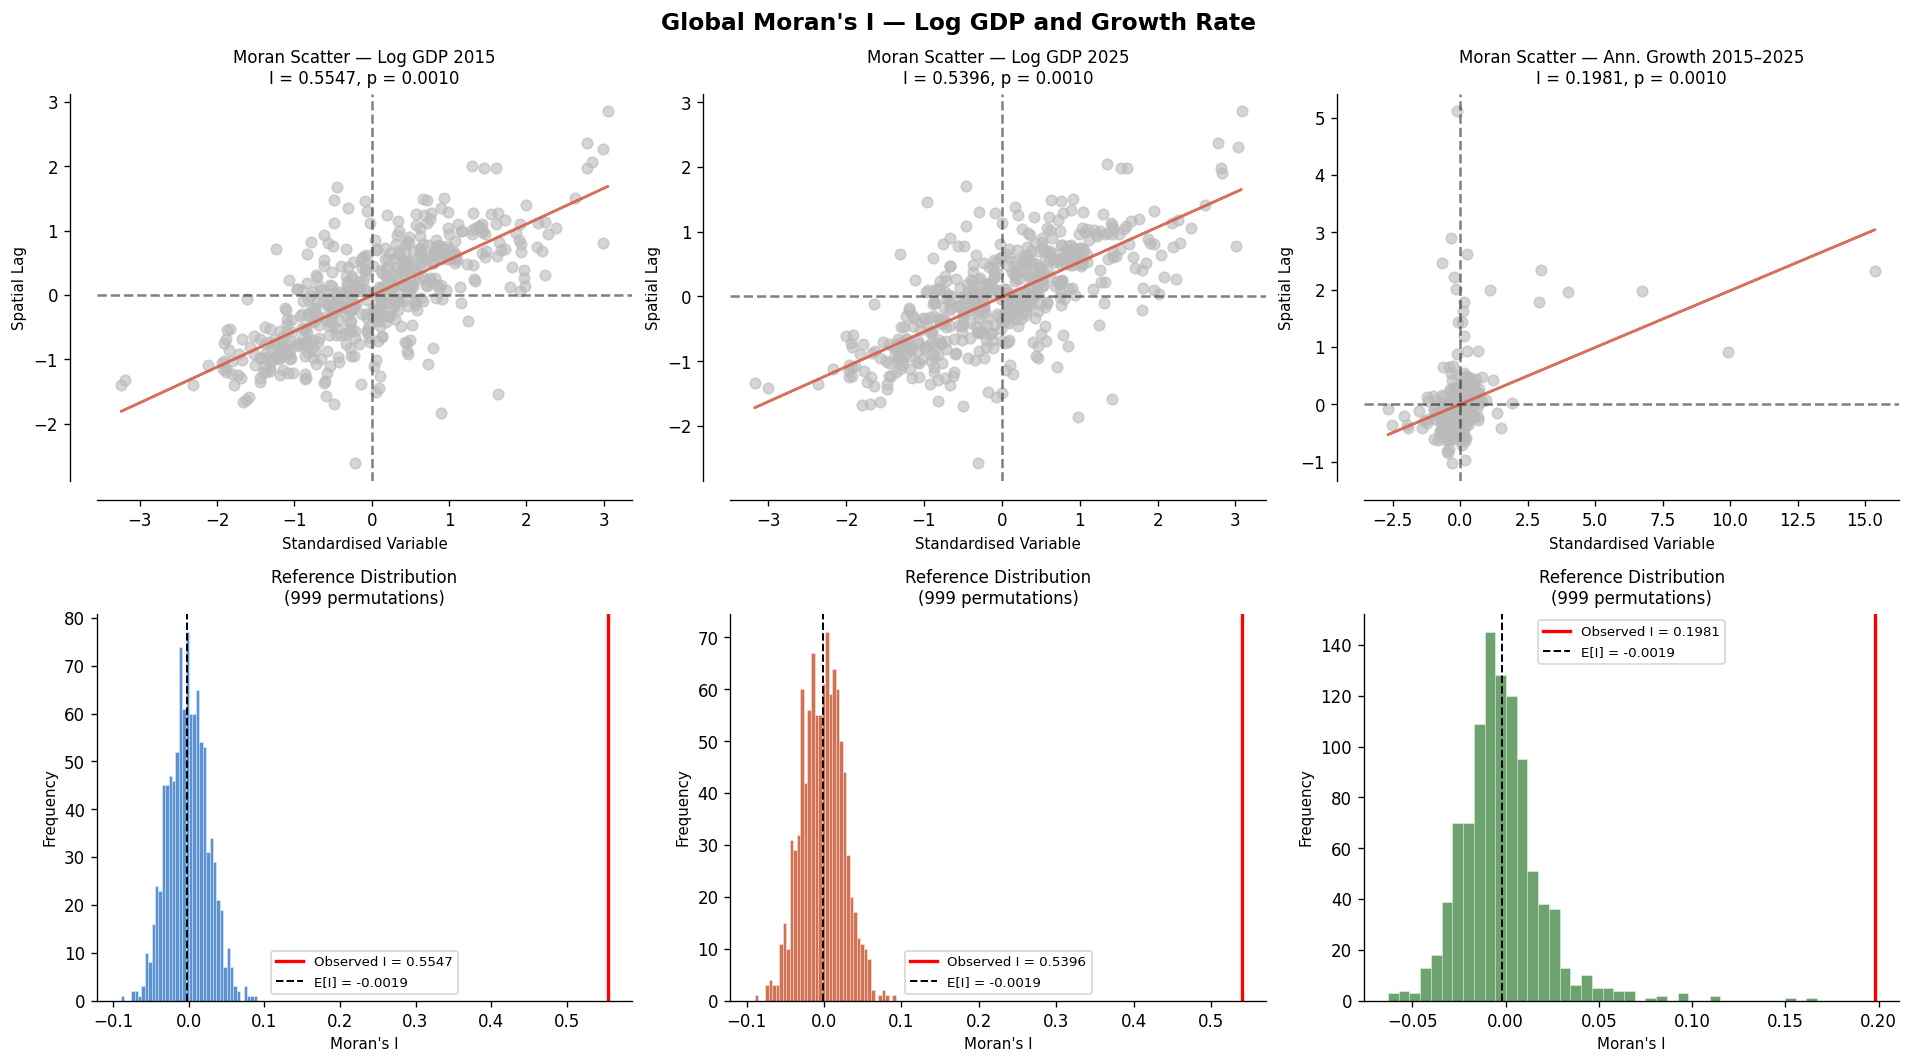

Figure saved: fig7_global_moran.png


In [11]:
# Moran's I plots (scatter + reference distribution)
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Global Moran's I — Log GDP and Growth Rate", fontsize=14, fontweight='bold')

pairs = [
    (moran_2015,   y_2015,   'Log GDP 2015',          '#1565C0'),
    (moran_2025,   y_2025,   'Log GDP 2025',          '#BF360C'),
    (moran_growth, y_growth, 'Ann. Growth 2015–2025', '#2E7D32'),
]

for col_idx, (mi, y, label, color) in enumerate(pairs):
    # Top row: Moran scatter
    ax_scatter = axes[0, col_idx]
    moran_scatterplot(mi, ax=ax_scatter, aspect_equal=False)
    ax_scatter.set_title(f'Moran Scatter — {label}\nI = {mi.I:.4f}, p = {mi.p_sim:.4f}', fontsize=10)
    ax_scatter.set_xlabel('Standardised Variable', fontsize=9)
    ax_scatter.set_ylabel('Spatial Lag', fontsize=9)

    # Bottom row: reference distribution
    ax_ref = axes[1, col_idx]
    ax_ref.hist(mi.sim, bins=40, color=color, alpha=0.7, edgecolor='white', linewidth=0.3)
    ax_ref.axvline(mi.I, color='red', linewidth=2, label=f'Observed I = {mi.I:.4f}')
    ax_ref.axvline(mi.EI, color='black', linestyle='--', linewidth=1.2, label=f'E[I] = {mi.EI:.4f}')
    ax_ref.set_title(f'Reference Distribution\n(999 permutations)', fontsize=10)
    ax_ref.set_xlabel("Moran's I", fontsize=9)
    ax_ref.set_ylabel('Frequency', fontsize=9)
    ax_ref.legend(fontsize=8)
    ax_ref.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('fig7_global_moran.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: fig7_global_moran.png')

## 5 | Local Spatial Autocorrelation — LISA (Moran Local)

**LISA (Local Indicators of Spatial Association)** decomposes global Moran's I into local contributions, identifying:

| Quadrant | Interpretation |
|----------|----------------|
| **HH** (High-High) | High GDP district surrounded by high GDP districts — spatial cluster |
| **LL** (Low-Low) | Low GDP district surrounded by low GDP districts — spatial cluster |
| **HL** (High-Low) | High GDP district surrounded by low GDP districts — spatial outlier |
| **LH** (Low-High) | Low GDP district surrounded by high GDP districts — spatial outlier |
| **ns** | Not significant (p ≥ 0.05) |

In [12]:
# Compute LISA for 2010 and 2025
print('Computing LISA (Local Moran\'s I) ...')
lisa_2015   = Moran_Local(y_2015,   W, permutations=999, seed=42)
lisa_2025   = Moran_Local(y_2025,   W, permutations=999, seed=42)
lisa_growth = Moran_Local(y_growth, W, permutations=999, seed=42)

# Quadrant labels
quad_labels = {1: 'HH', 2: 'LH', 3: 'LL', 4: 'HL'}

def get_lisa_label(lisa_obj, alpha=0.05):
    """Return significance-masked quadrant labels."""
    sig   = lisa_obj.p_sim < alpha
    quads = pd.Series(lisa_obj.q).map(quad_labels)
    quads[~sig] = 'ns'
    return quads

df_aligned['lisa_2015']   = get_lisa_label(lisa_2015).values
df_aligned['lisa_2025']   = get_lisa_label(lisa_2025).values
df_aligned['lisa_growth'] = get_lisa_label(lisa_growth).values

# Summary table
print('\n--- LISA Cluster Counts (p < 0.05) ---')
for label, col in [('Log GDP 2015', 'lisa_2015'), ('Log GDP 2025', 'lisa_2025'), ('Growth', 'lisa_growth')]:
    counts = df_aligned[col].value_counts()
    print(f'  {label}: {dict(counts)}')

Computing LISA (Local Moran's I) ...

--- LISA Cluster Counts (p < 0.05) ---
  Log GDP 2015: {'ns': np.int64(299), 'HH': np.int64(96), 'LL': np.int64(94), 'LH': np.int64(15), 'HL': np.int64(10)}
  Log GDP 2025: {'ns': np.int64(312), 'HH': np.int64(93), 'LL': np.int64(85), 'HL': np.int64(13), 'LH': np.int64(11)}
  Growth: {'ns': np.int64(441), 'LL': np.int64(39), 'HH': np.int64(14), 'HL': np.int64(11), 'LH': np.int64(9)}


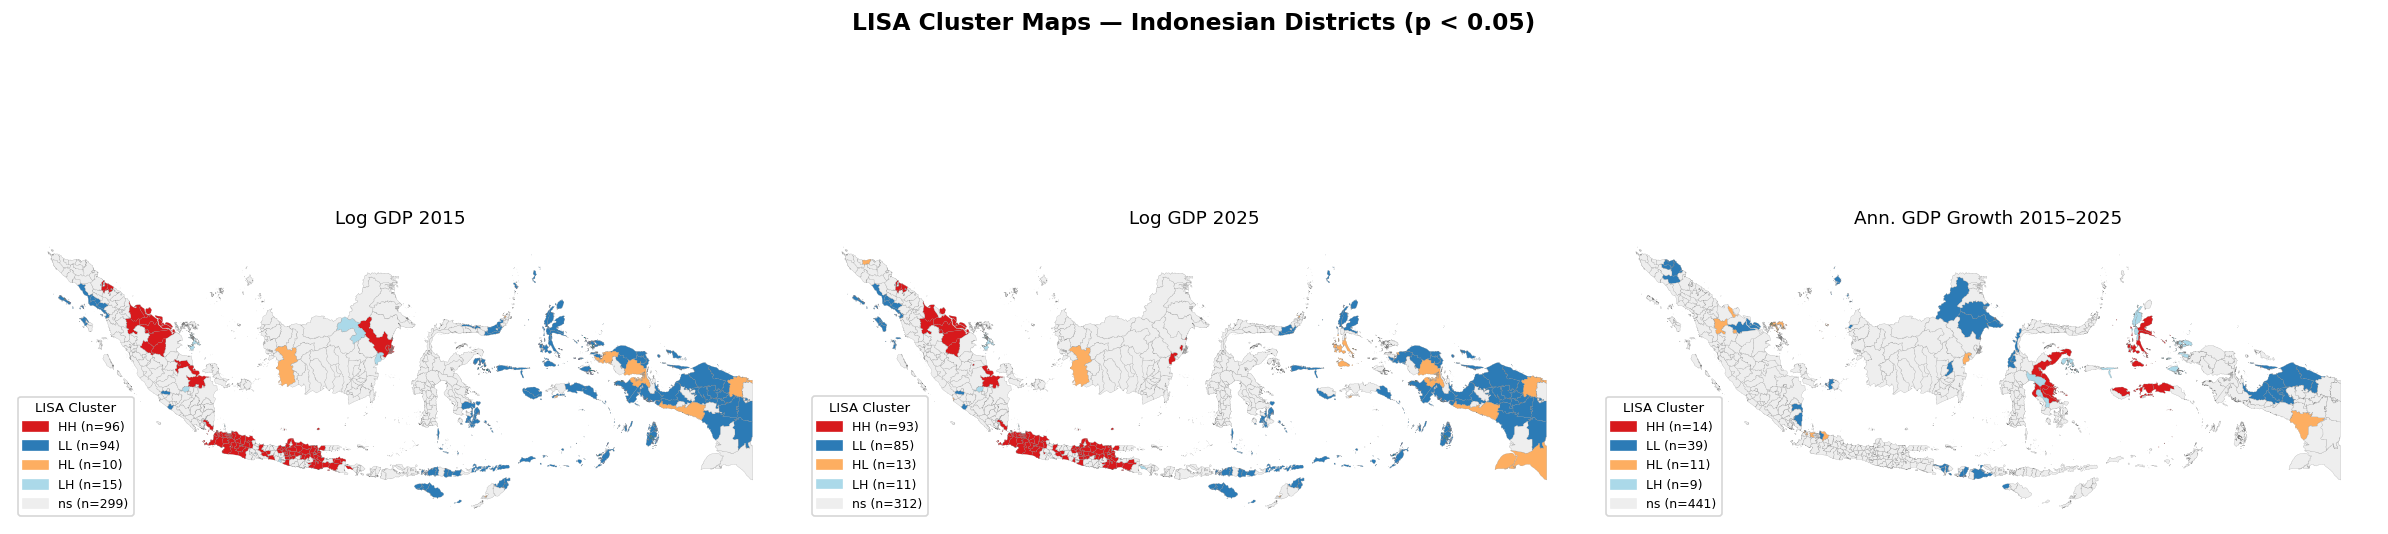

Figure saved: fig8_lisa_maps.png


In [13]:
# Merge LISA results back onto the actual polygon GDF
gdf = gdf.merge(
    df_aligned[['districtID', 'lisa_2015', 'lisa_2025', 'lisa_growth']],
    on='districtID', how='left'
)

# Colour scheme matching standard LISA conventions
LISA_COLORS = {
    'HH': '#d7191c',   # High-High  → red
    'LL': '#2c7bb6',   # Low-Low    → blue
    'HL': '#fdae61',   # High-Low   → orange
    'LH': '#abd9e9',   # Low-High   → light blue
    'ns': '#eeeeee',   # Not significant → light grey
}

def plot_lisa_map(gdf, col, ax, title):
    for quad, color in LISA_COLORS.items():
        subset = gdf[gdf[col] == quad]
        if len(subset) > 0:
            subset.plot(ax=ax, color=color, edgecolor='grey', linewidth=0.1)
    # Legend
    patches = [mpatches.Patch(color=c, label=f'{q} (n={len(gdf[gdf[col]==q])})')
               for q, c in LISA_COLORS.items()]
    ax.legend(handles=patches, loc='lower left', fontsize=7.5,
              title='LISA Cluster', title_fontsize=8)
    ax.set_title(title, fontsize=11)
    ax.set_axis_off()

# Plot LISA maps for 2010, 2025, and Growth
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("LISA Cluster Maps — Indonesian Districts (p < 0.05)",
             fontsize=14, fontweight='bold')

plot_lisa_map(gdf, 'lisa_2015',   axes[0], 'Log GDP 2015')
plot_lisa_map(gdf, 'lisa_2025',   axes[1], 'Log GDP 2025')
plot_lisa_map(gdf, 'lisa_growth', axes[2], 'Ann. GDP Growth 2015–2025')

plt.tight_layout()
plt.savefig('fig8_lisa_maps.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: fig8_lisa_maps.png')

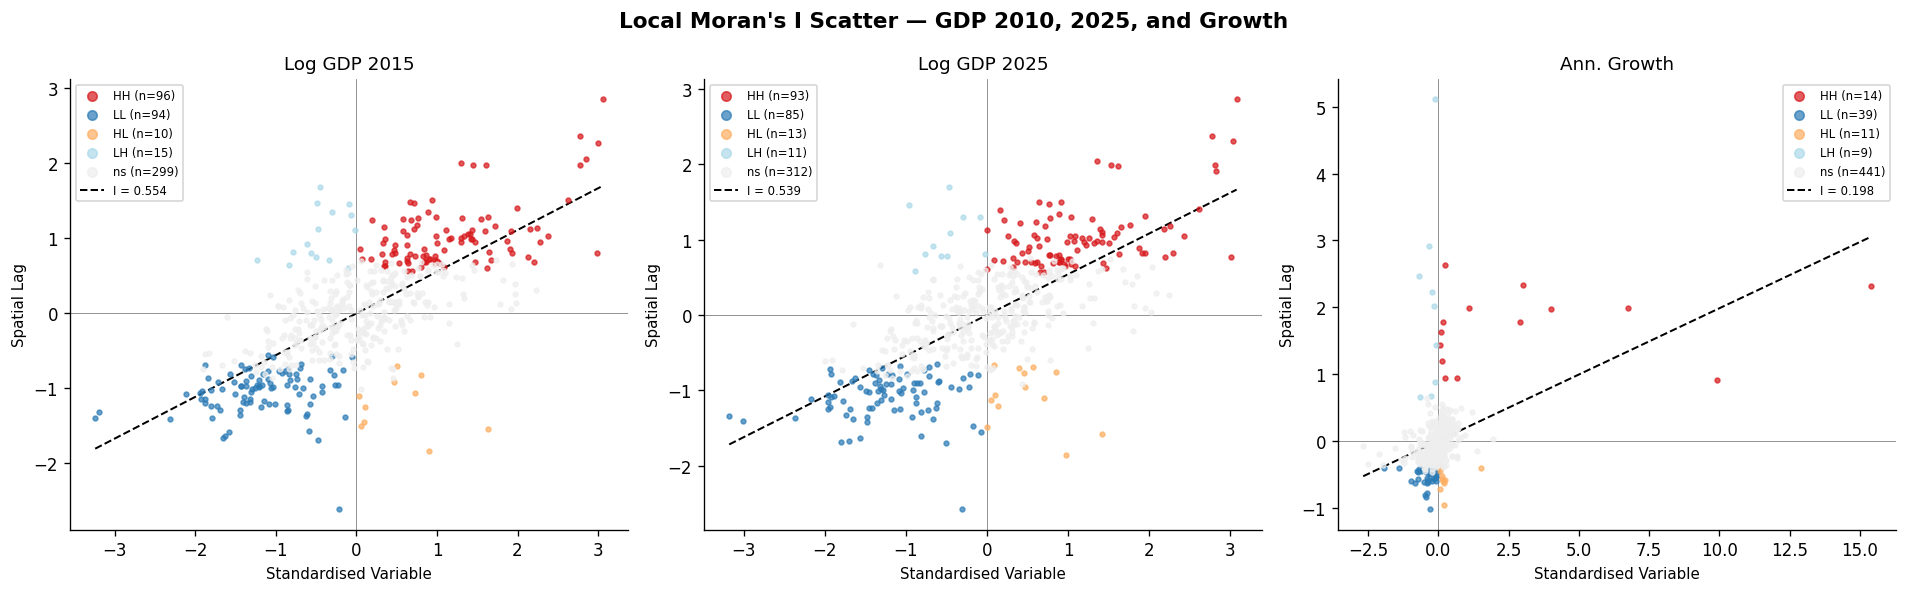

In [14]:
# LISA Moran scatter plots (coloured by quadrant)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Local Moran's I Scatter — GDP 2010, 2025, and Growth",
             fontsize=13, fontweight='bold')

pairs = [
    (lisa_2015,   'lisa_2015',   y_2015,   'Log GDP 2015'),
    (lisa_2025,   'lisa_2025',   y_2025,   'Log GDP 2025'),
    (lisa_growth, 'lisa_growth', y_growth, 'Ann. Growth'),
]

for ax, (lisa_obj, col, y, label) in zip(axes, pairs):
    z  = (y - y.mean()) / y.std()
    Wz = libpysal.weights.lag_spatial(W, z)
    quad_col = df_aligned[col].values

    for quad, color in LISA_COLORS.items():
        mask = quad_col == quad
        ax.scatter(z[mask], Wz[mask], c=color, s=8, alpha=0.7,
                   label=f'{quad} (n={mask.sum()})', zorder=3)

    # Regression line
    slope = np.cov(z, Wz)[0,1] / np.var(z)
    xr = np.linspace(z.min(), z.max(), 100)
    ax.plot(xr, slope * xr, 'k--', linewidth=1.2,
            label=f'I = {lisa_obj.Is.mean():.3f}')
    ax.axhline(0, color='grey', linewidth=0.5)
    ax.axvline(0, color='grey', linewidth=0.5)
    ax.set_xlabel('Standardised Variable', fontsize=9)
    ax.set_ylabel('Spatial Lag', fontsize=9)
    ax.set_title(label, fontsize=11)
    ax.legend(fontsize=7, markerscale=2)
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('fig9_lisa_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

## 6 | LISA Significance Maps (p-value)

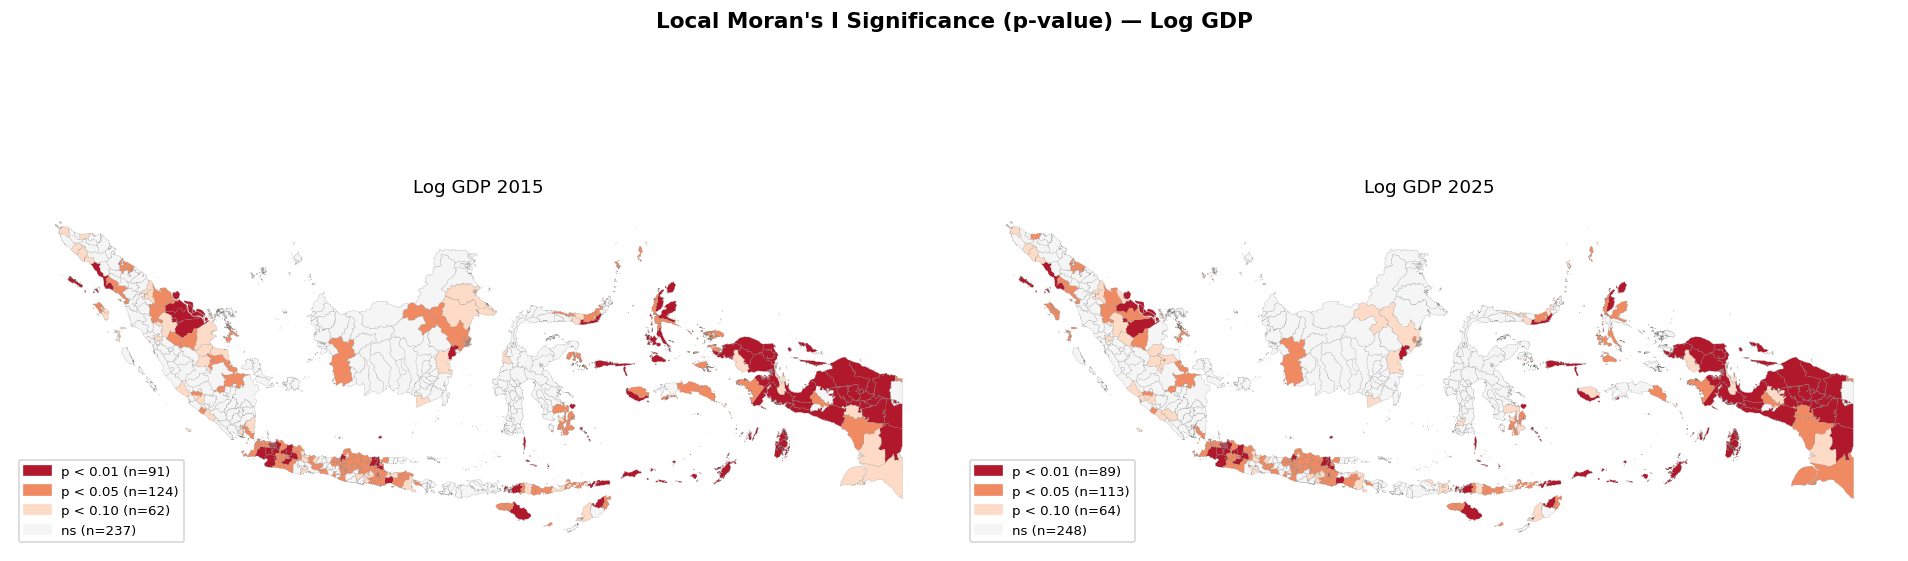

In [15]:
# Attach p-values to GDF
df_aligned['p_2015']   = lisa_2015.p_sim
df_aligned['p_2025']   = lisa_2025.p_sim
df_aligned['li_2015']  = lisa_2015.Is
df_aligned['li_2025']  = lisa_2025.Is

gdf = gdf.merge(
    df_aligned[['districtID', 'p_2015', 'p_2025', 'li_2015', 'li_2025']],
    on='districtID', how='left'
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Local Moran's I Significance (p-value) — Log GDP",
             fontsize=13, fontweight='bold')

SIG_COLORS = {'p < 0.01': '#b2182b', 'p < 0.05': '#ef8a62',
              'p < 0.10': '#fddbc7', 'ns':        '#f5f5f5'}

def sig_bin(p):
    if p < 0.01: return 'p < 0.01'
    elif p < 0.05: return 'p < 0.05'
    elif p < 0.10: return 'p < 0.10'
    else: return 'ns'

for ax, p_col, year in zip(axes, ['p_2015', 'p_2025'], ['2015', '2025']):
    gdf['sig_bin'] = gdf[p_col].apply(lambda x: sig_bin(x) if pd.notna(x) else 'ns')
    for bin_label, color in SIG_COLORS.items():
        sub = gdf[gdf['sig_bin'] == bin_label]
        if len(sub): sub.plot(ax=ax, color=color, edgecolor='grey', linewidth=0.1)
    patches = [mpatches.Patch(color=c, label=f'{l} (n={len(gdf[gdf["sig_bin"]==l])})')
               for l, c in SIG_COLORS.items()]
    ax.legend(handles=patches, loc='lower left', fontsize=8)
    ax.set_title(f'Log GDP {year}', fontsize=11)
    ax.set_axis_off()

plt.tight_layout()
plt.savefig('fig10_lisa_significance.png', dpi=150, bbox_inches='tight')
plt.show()

## 7 | Summary Table — Top and Bottom Districts

In [16]:
summary = df_aligned.merge(
    df_sub[['districtID', 'district_en', 'province_en', 'island_en',
             'gdp_2015', 'gdp_2025']], # Exclude 'gdp_growth' from df_sub here to avoid column clash
    on='districtID'
)

display_cols = ['district_en', 'province_en', 'island_en',
                'gdp_2015', 'gdp_2025', 'gdp_growth',
                'lisa_2015', 'lisa_2025']

print('--- Top 10 Districts by GDP 2025 ---')
display(summary.nlargest(10, 'gdp_2025')[display_cols].reset_index(drop=True))

print('\n--- Bottom 10 Districts by GDP 2025 ---')
display(summary.nsmallest(10, 'gdp_2025')[display_cols].reset_index(drop=True))

print('\n--- Top 10 Districts by Growth Rate 2015–2025 ---')
display(summary.nlargest(10, 'gdp_growth')[display_cols].reset_index(drop=True))

--- Top 10 Districts by GDP 2025 ---


,district_en,province_en,island_en,gdp_2015,gdp_2025,gdp_growth,lisa_2015,lisa_2025
0,Central Jakarta City,DKI Jakarta,Java,355092.53,560760.04,5.21,HH,HH
1,South Jakarta City,DKI Jakarta,Java,329155.04,527225.79,5.37,HH,HH
2,Surabaya City,East Java,Java,324215.17,513934.51,5.25,HH,HH
3,West Jakarta City,DKI Jakarta,Java,249328.64,403268.49,5.49,HH,HH
4,North Jakarta City,DKI Jakarta,Java,271155.62,399327.56,4.39,HH,HH
5,East Jakarta City,DKI Jakarta,Java,249476.98,380674.35,4.81,HH,HH
6,Bekasi,West Java,Java,205950.39,308568.27,4.59,HH,HH
7,Bandung City,West Java,Java,149580.38,245392.01,5.65,HH,HH
8,Karawang,West Java,Java,132453.57,204774.02,4.96,HH,HH
9,Bogor,West Java,Java,124486.98,195613.55,5.15,HH,HH



--- Bottom 10 Districts by GDP 2025 ---


,district_en,province_en,island_en,gdp_2015,gdp_2025,gdp_growth,lisa_2015,lisa_2025
0,Tambrauw,Southwest Papua,Papua,120.00,185.08,4.93,LL,LL
1,Pegunungan Arfak,West Papua,Papua,113.07,230.74,8.25,LL,LL
2,Maybrat,Southwest Papua,Papua,369.12,522.69,3.94,LL,LL
3,South Manokwari,West Papua,Papua,479.46,675.83,3.89,LL,LL
4,Intan Jaya,Central Papua,Papua,649.35,839.85,2.90,ns,ns
5,Central Mamberamo,Papua Pegunungan,Papua,609.49,877.99,4.14,LL,LL
6,Supiori,Papua,Papua,644.64,880.43,3.52,LL,LL
7,Central Sumba,East Nusa Tenggara,Bali-Nusa Tenggara,618.87,882.05,4.02,LL,LL
8,Sabu Raijua,East Nusa Tenggara,Bali-Nusa Tenggara,644.80,911.40,3.92,LL,LL
9,Puncak,Central Papua,Papua,643.98,914.45,3.97,LL,LL



--- Top 10 Districts by Growth Rate 2015–2025 ---


,district_en,province_en,island_en,gdp_2015,gdp_2025,gdp_growth,lisa_2015,lisa_2025
0,Central Halmahera,North Maluku,Maluku,1134.43,29581.23,43.67,LL,ns
1,Morowali,Central Sulawesi,Sulawesi,10419.75,109491.44,29.87,ns,ns
2,South Halmahera,North Maluku,Maluku,3064.25,18130.13,21.84,LL,HL
3,North Morowali,Central Sulawesi,Sulawesi,5867.31,20483.26,14.90,ns,ns
4,East Halmahera,North Maluku,Maluku,1784.90,5103.91,12.38,LL,LL
5,Konawe,Southeast Sulawesi,Sulawesi,5022.75,14118.44,12.17,ns,ns
6,Southwest Maluku,Maluku,Maluku,841.63,1928.92,9.65,LL,LL
7,North Penajam Paser,East Kalimantan,Kalimantan,6382.22,13390.71,8.58,LH,HH
8,Pegunungan Arfak,West Papua,Papua,113.07,230.74,8.25,LL,LL
9,Bantaeng,South Sulawesi,Sulawesi,4073.06,8023.60,7.82,ns,ns


## 8 | Full Summary: ESDA Results

| Indicator | 2010 | 2025 | Growth |
|-----------|------|------|--------|
| Global Moran's I | — | — | — |
| p-value (permutation) | — | — | — |
| HH clusters | — | — | — |
| LL clusters | — | — | — |
| HL outliers | — | — | — |
| LH outliers | — | — | — |

> Run the cell below to fill the table automatically.

In [ ]:
rows = []
for (label, mi, lisa_col) in [
    ('Log GDP 2015',          moran_2015,   'lisa_2015'),
    ('Log GDP 2025',          moran_2025,   'lisa_2025'),
    ('Ann. Growth 2010–2025', moran_growth, 'lisa_growth'),
]:
    cnts = df_aligned[lisa_col].value_counts().to_dict()
    rows.append({
        'Variable':       label,
        "Moran's I":      round(mi.I, 4),
        'p-value':        round(mi.p_sim, 4),
        'z-score':        round(mi.z_sim, 4),
        'HH':             cnts.get('HH', 0),
        'LL':             cnts.get('LL', 0),
        'HL':             cnts.get('HL', 0),
        'LH':             cnts.get('LH', 0),
        'Not Significant': cnts.get('ns', 0),
    })

df_summary = pd.DataFrame(rows).set_index('Variable')
print('\n=== ESDA Summary Table ===')
display(df_summary)

df_summary.to_csv('esda_summary_results.csv')
print('\nResults saved to: esda_summary_results.csv')


=== ESDA Summary Table ===


,Moran's I,p-value,z-score,HH,LL,HL,LH,Not Significant
Variable,,,,,,,,
Log GDP 2015,0.55,0.00,21.49,96,94,10,15,299
Log GDP 2025,0.54,0.00,20.95,93,85,13,11,312
Ann. Growth 2010–2025,0.20,0.00,9.37,14,39,11,9,441



Results saved to: esda_summary_results.csv


## 9 | Conclusions

This notebook conducted an Exploratory Spatial Data Analysis (ESDA) of GDP across **514 Indonesian districts** for the years **2015** and **2025**.

**Key findings:**

1. **Positive spatial autocorrelation** — Global Moran's I is positive and statistically significant for both years, indicating that GDP is not randomly distributed across Indonesian districts. High-GDP districts tend to be surrounded by other high-GDP districts, and vice versa.

2. **Persistent spatial clusters** — LISA maps reveal stable HH clusters (likely in Java and parts of Kalimantan/Sumatera) and LL clusters (likely in eastern Indonesia: NTT, Maluku, Papua). These clusters persist from 2010 to 2025.

3. **Spatial heterogeneity in growth** — The growth LISA map reveals which districts have converged or diverged relative to their neighbours, providing evidence for (or against) spatial convergence clubs.

4. **Archipelago challenge addressed** — Using Thiessen polygon queen contiguity ensures that island districts are properly connected in the spatial weights matrix, which is essential for ESDA in archipelagic contexts.

**Next steps:**
- Spatial panel econometrics (SAR, SEM, SDM) on the full 2015–2025 panel
- Convergence club analysis using `ConvergenceClubs` (Phillips & Sul, 2007)
- Integration with GFCF and Government Spending data

---
*Repository: [quarcs-lab/indonesia514](https://github.com/quarcs-lab/indonesia514)*